In [1]:
import pandas as pd
import numpy as np

from scipy.sparse import csr_matrix

import matplotlib.pyplot as plt

In [2]:
ratings = pd.read_csv('../ml-25m/ratings.csv')

In [3]:
print("Ratings:", len(ratings))

print("Users:",
      ratings['userId'].nunique())

print("Movies:",
      ratings['movieId'].nunique())

Ratings: 25000095
Users: 162541
Movies: 59047


In [5]:
user_ids = ratings['userId'].unique()

user_map = {
    old:new
    for new, old
    in enumerate(user_ids)
}
list(user_map.items())[:5]


[(np.int64(1), 0),
 (np.int64(2), 1),
 (np.int64(3), 2),
 (np.int64(4), 3),
 (np.int64(5), 4)]

In [7]:
movie_ids = ratings['movieId'].unique()

movie_map = {
    old:new
    for new, old
    in enumerate(movie_ids)
}
list(movie_map.items())[:5]


[(np.int64(296), 0),
 (np.int64(306), 1),
 (np.int64(307), 2),
 (np.int64(665), 3),
 (np.int64(899), 4)]

In [9]:
ratings['user_idx'] = ratings['userId'].map(user_map)

ratings['movie_idx'] = ratings['movieId'].map(movie_map)

ratings.head()

,userId,movieId,rating,timestamp,user_idx,movie_idx
0,1,296,5.0,1147880044,0,0
1,1,306,3.5,1147868817,0,1
2,1,307,5.0,1147868828,0,2
3,1,665,5.0,1147878820,0,3
4,1,899,3.5,1147868510,0,4


In [10]:
R = csr_matrix(
    (
        ratings['rating'],
        (
            ratings['user_idx'],
            ratings['movie_idx']
        )
    )
)

In [11]:
print("Matrix Shape:")
print(R.shape)

Matrix Shape:
(162541, 59047)


In [12]:
print("Ratings Stored:")
print(R.nnz)

Ratings Stored:
25000095


In [13]:
density = R.nnz / (
    R.shape[0] *
    R.shape[1]
)

print("Density:", density)


Density: 0.002604839052572928


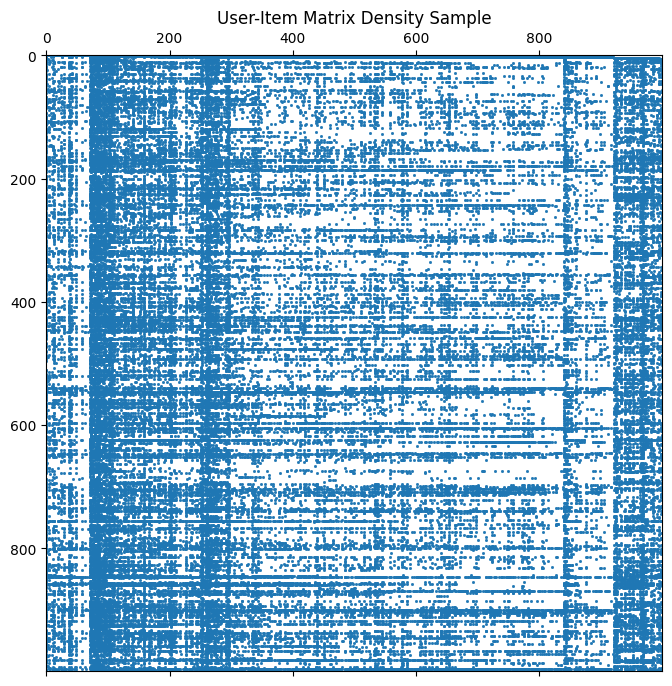

In [15]:
sample = R[:1000, :1000]

plt.figure(figsize=(8,8))

plt.spy(
    sample,
    markersize=1
)

plt.title(
    "User-Item Matrix Density Sample"
)

plt.show()


In [16]:
import pickle

with open('../user_map.pkl','wb') as f:
    pickle.dump(user_map,f)

with open('../movie_map.pkl','wb') as f:
    pickle.dump(movie_map,f)

# Day 2 — User-Item Matrix Construction

## Objective

Transform the MovieLens ratings dataset into a user-item interaction matrix suitable for Collaborative Filtering and Singular Value Decomposition (SVD).

---

## Tasks Completed

### 1. Dataset Loading

* Loaded ratings.csv
* Verified dataset dimensions
* Confirmed user count, movie count, and total ratings

### 2. User ID Mapping

Created a mapping from original user IDs to continuous matrix indices.

Example:

Original User ID → Matrix Index

1 → 0

2 → 1

3 → 2

This mapping enables efficient matrix construction.

### 3. Movie ID Mapping

Created a mapping from original movie IDs to continuous matrix indices.

Example:

Original Movie ID → Matrix Index

1 → 0

3 → 1

5 → 2

This mapping enables efficient matrix construction.

### 4. Matrix Index Generation

Added:

* user_idx
* movie_idx

columns to the ratings dataset.

These indices are used to position ratings inside the user-item matrix.

### 5. Sparse Matrix Construction

Constructed a Compressed Sparse Row (CSR) matrix using SciPy.

Matrix Representation:

Rows    → Users

Columns → Movies

Values  → Ratings

CSR format was selected because the dataset is highly sparse and storing a dense matrix would require excessive memory.

### 6. Matrix Statistics

Recorded:

* Number of users
* Number of movies
* Matrix dimensions
* Number of non-zero entries (ratings)

### 7. Density Analysis

Calculated matrix density using:

Density = Non-Zero Entries / (Rows × Columns)

Observation:

The matrix contains only a very small percentage of filled entries, confirming the sparsity observed during Day 1.

### 8. Matrix Visualization

Generated a sparse matrix density plot using a sample of the user-item matrix.

Observation:

Ratings are distributed sparsely across the matrix with the majority of entries remaining empty.

### 9. Mapping Persistence

Saved:

* user_map.pkl
* movie_map.pkl

These files will be reused during recommendation generation and model deployment.

---

## Key Findings

1. Successfully transformed raw ratings into a mathematical matrix representation.
2. Confirmed that the MovieLens dataset is highly sparse.
3. CSR sparse matrix significantly reduces memory consumption.
4. User and movie mappings are required for matrix factorization algorithms.
5. User-item matrix is now ready for Singular Value Decomposition (SVD).

---

## Deliverables Produced

* 02_UserItemMatrix.ipynb
* CSR User-Item Matrix
* User ID Mapping
* Movie ID Mapping
* Density Visualization
* Saved Mapping Files

---

## Status

Day 2: COMPLETED ✅

Next Stage:
Day 3 — Singular Value Decomposition (SVD)
